# ML - Aprendizaje No Supervisado

La mayoría de datasets tienen sus datos no etiquetados. Por lo que podemos etiquetar datos manualmente o usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Clustering

Consiste en identificar muestras similares del conjunto de datos y asignarlas a un grupo denominado *cluster*. Ayudandonos a descubrir patrones en los datos

### K-Means

 Generaremos un conjunto de datos sintético para aplicar K-Means que es un método rápido y eficiente a la hora de aplicar *Clustering*.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

# Número aleatorio de centroides entre 1 y 20
n_centers = random.randint(1, 20)

# Generar centros aleatorios con distancia entre ellos
blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-30, 30, size=2)
    if all(np.linalg.norm(candidate - center) > 8 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)  # desviación estándar uniforme


from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)


print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 4
Coordenadas de los centroides:
[[ 15.15710818  28.07989738]
 [ -7.84957847   8.12504688]
 [ -4.61409229  21.94837821]
 [-17.66054801 -22.13327802]]


In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

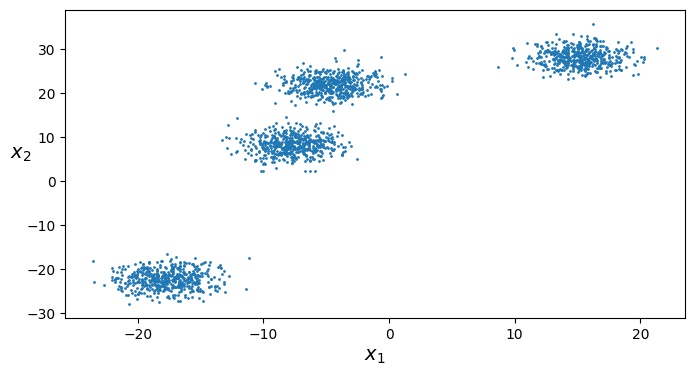

In [ ]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [ ]:
from sklearn.cluster import KMeans
#usaremos la cantidad de centroides como cantidad de clusters
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred         #devolver las etiques de cada grupo y

array([3, 1, 0, ..., 1, 2, 0], dtype=int32)

In [ ]:
kmeans.cluster_centers_  # centro de los clusters

array([[ -7.72403629,   8.28284965],
       [ 15.16431058,  28.1500232 ],
       [-17.68335825, -22.18534466],
       [ -4.63455174,  21.99217452]])

In [ ]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])  #Predecir nuevas ubicaciones
kmeans.predict(X_new)

array([0, 0, 0, 0], dtype=int32)

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

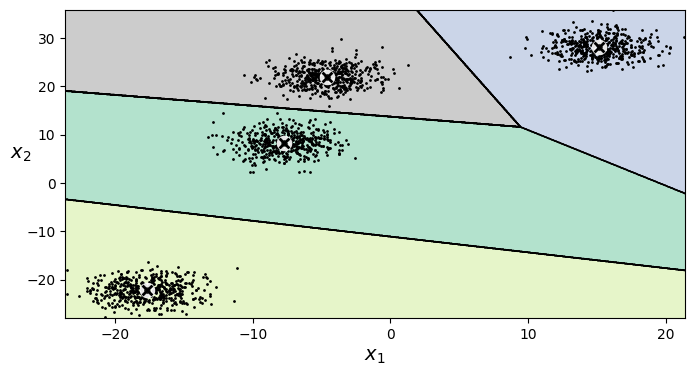

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [ ]:
kmeans.transform(X_new)  # la  distancia de cada punto del X_neww

array([[ 9.95665287, 30.22879469, 29.96050826, 20.52233202],
       [12.42896432, 28.84084196, 31.82345368, 21.4003136 ],
       [ 7.08696122, 31.02363366, 29.15308894, 19.06238317],
       [ 7.46711919, 31.43033358, 28.72224313, 19.56058861]])

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [ ]:
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)

kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(algorithm='elkan', max_iter=3, n_clusters=4, n_init=1, random_state=5)

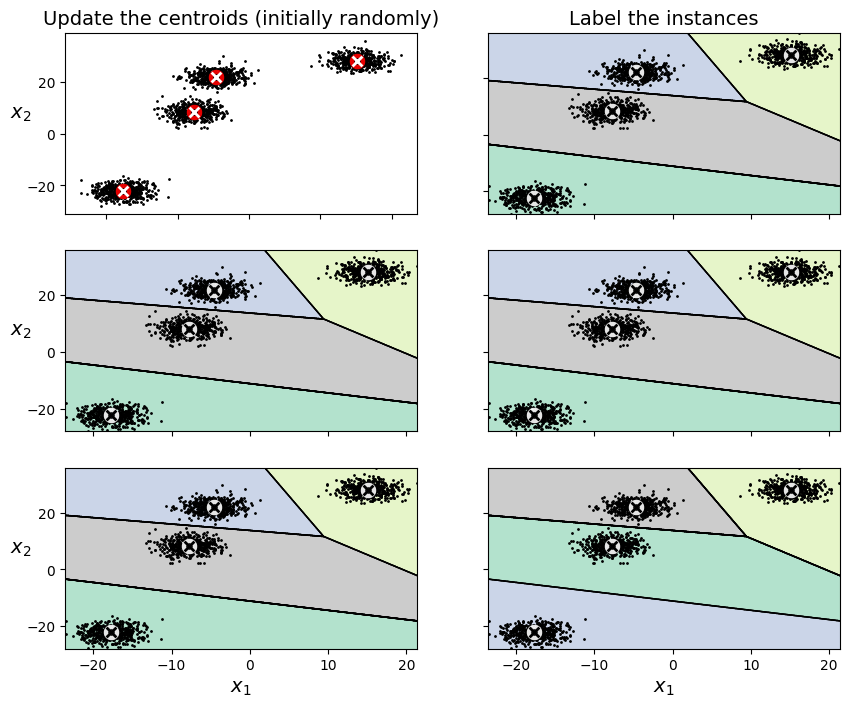

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

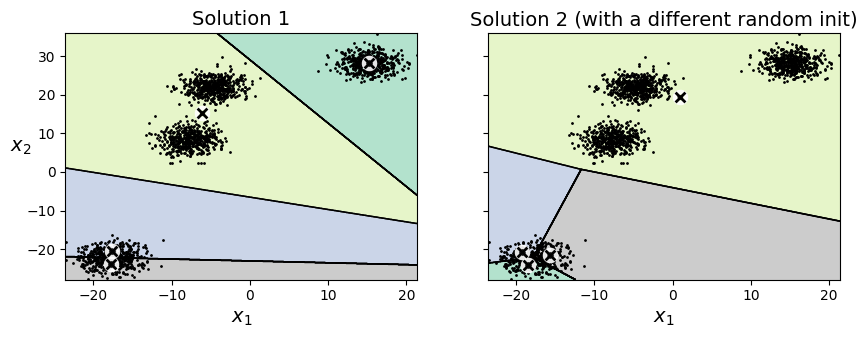

In [ ]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)        # inicializando 10 y quedandome con el mejor resultado
kmeans_rnd_10_inits.fit(X)

KMeans(algorithm='elkan', init='random', n_clusters=4, n_init=10,
       random_state=11)

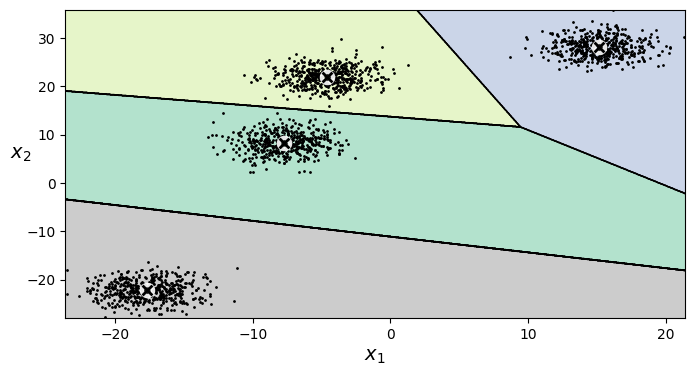

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Otras mejoras al algoritmo de *K-Means* incluyen: *K-Means* acelerados, usado por *Scikit-Learn* por defecto y que evita algunos cálculos de distancias, y *mini-batch K-Means*, que puedes usarse si el dataset es tan grande que no cabe en memoria, pero no teniendo resultados tan precisos. Veremos como funciona con el dataset MNIST, para lo cual usaremos el objeto *MiniBatchKMeans*,.

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
mnist.target = mnist.target.astype(np.int64)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    mnist["data"], mnist["target"], random_state=42)

In [ ]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [ ]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None # aqui creamosS variable para guardar el mejor modelo entrenado
# el entrenamiento de Mini-bacht kmeans
for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [ ]:
best_kmeans.score(X)

-14530.723996117124

El algoritmo de *mini-batch K-Means* es más rápido que *K-Means* normal, pero su precisión suele ser peor.

### Encontrando el número óptimo de grupos

El número de grupos o *clusters* es un parámetro del modelo que debemos definir, y si nuestros datos no están etiquetados será difícil saber qué valor usar. Por lo que, se usa diferentes valores y alguna métrica significativa como el *silhouette score*, que se basa en calcular el coeficiente de silueta (*silhouette coefficient*) que indica que tan bien está la muestra dentro de su cluster. Un valor cercano a $1$ indica que la muestra está bien metida en su grupo, mientras que un valor cercano a $0$ indica que la muestra se encuentra cerca de una frontera de decisión y un valor cercano a $-1$ indica que la muestra está en el grupo incorrecto.

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.8042805271349787)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

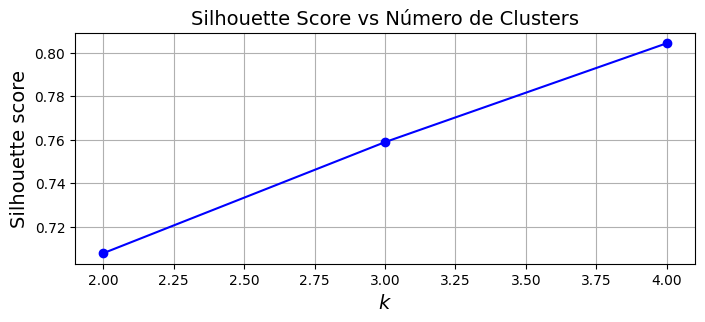

In [ ]:
import matplotlib.pyplot as plt

# Definir máximo valor de k
max_k = min(20, len(blob_centers))

# Entrenar un modelo KMeans para cada k de 1 hasta max_k
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]

# Calcular silhouette_scores para k ≥ 2
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

# Generar eje x para k de 2 hasta max_k
ks = list(range(2, max_k + 1))

# Graficar
plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()


###Método del Codo (Elbow Method)

La inercia es la suma de las distancias al cuadrado de cada muestra a su centroide mas cercano. Al graficarla en funcion de k, se busca el punto donde la curva deja de descender bruscamente, es decir, el codo. Ese punto indica el k a partir del cual agregar mas clusters no aporta una mejora significativa.


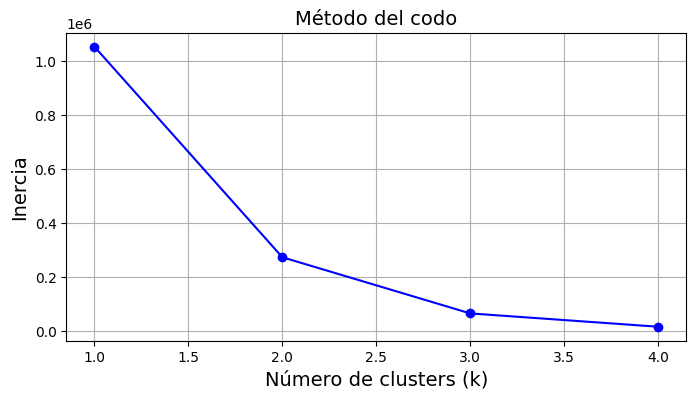

In [ ]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

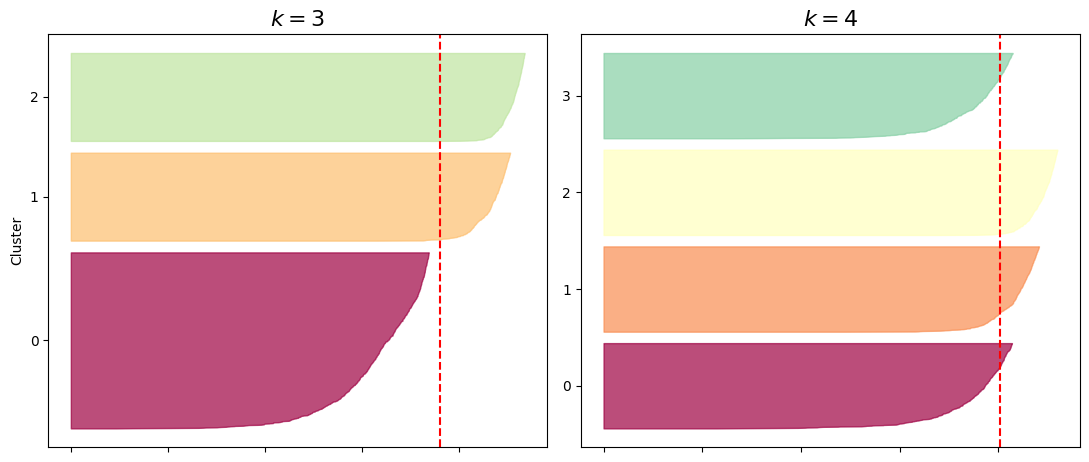

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=16)

plt.tight_layout()
plt.show()


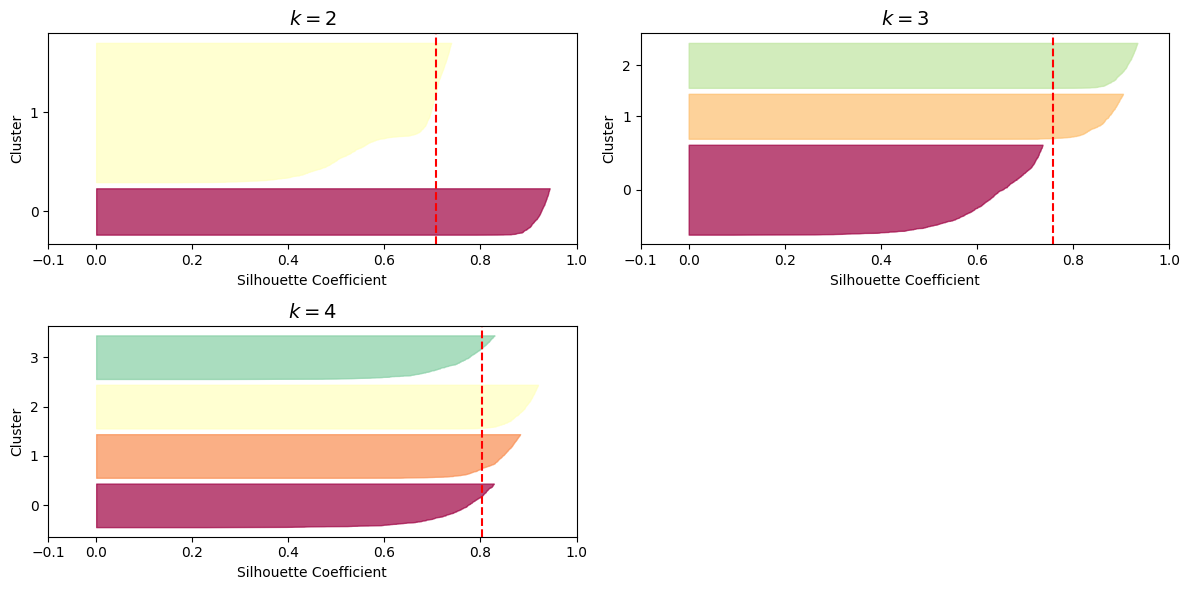

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()


---
## PUNTO 2 - Dataset CUB-200-2011: Aprendizaje Semi-supervisado y Activo

### Descripcion del dataset

CUB-200-2011 es un dataset de imagenes de aves con las siguientes caracteristicas:

| Caracteristica       | Valor                                        |
|----------------------|----------------------------------------------|
| Carpetas (clases)    | 200 especies de aves                         |
| Total de imagenes    | aproximadamente 11 788                       |
| Caracteristicas (n)  | 64 x 64 x 3 = 12 288 pixeles por imagen     |
| Ejemplos (m)         | 11 788 (cumple m > 10 000)                   |
| Etiquetas            | Existen pero las trataremos como desconocidas |

Las imagenes estan organizadas en subcarpetas por especie dentro de la carpeta `images`. Para simular un escenario completamente no supervisado hacemos lo siguiente:

1. Recorremos todas las subcarpetas y cargamos todas las imagenes juntas.
2. Mezclamos el orden aleatoriamente.
3. Fingimos que no sabemos cuantas clases hay ni a que especie pertenece cada imagen.
4. Aplicamos KMeans para descubrir estructura en los datos.
5. Usamos el metodo del codo y el silhouette score para estimar el numero de grupos.

Las etiquetas reales solo se usan al final para evaluar el clasificador

### 2.1 Carga del dataset desde Google Drive

Las imagenes se leen directamente desde la ruta en Google Drive. Se redimensionan a 64x64 pixeles y se aplanan en vectores de 12 288 valores, normalizados entre 0 y 1. Las etiquetas reales se guardan aparte y no se usan durante el proceso no supervisado.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

# -----------------------------------------------------------------------
# RUTA AL DATASET EN GOOGLE DRIVE
# Las imagenes estan en subcarpetas por especie dentro de esta ruta.
# Ejemplo de estructura:
#   images/
#     001.Black_footed_Albatross/  <- carpeta de la especie 1
#       Black_Footed_Albatross_0001_796111.jpg
#       ...
#     002.Laysan_Albatross/        <- carpeta de la especie 2
#       ...
#     ...
# -----------------------------------------------------------------------
IMAGES_ROOT = "/content/drive/MyDrive/SIS420/Aprendizaje No Supervisado/Datasets/LAB07/images"
IMG_SIZE    = 64   # Redimensionar cada imagen a 64x64 pixeles

def load_cub_images(images_root, img_size=64):
    """
    Recorre todas las subcarpetas de images_root, carga las imagenes,
    las redimensiona y las aplana. Devuelve X (features), y (etiquetas
    numericas reales) y class_names (nombres de las carpetas).

    Las imagenes se mezclan aleatoriamente para simular que no conocemos
    la organizacion por clases.
    """
    X_list      = []
    y_list      = []
    class_names = []

    # Ordenar subcarpetas para asignar indices de clase reproducibles
    folders = sorted([
        f for f in os.listdir(images_root)
        if os.path.isdir(os.path.join(images_root, f))
    ])

    print(f"Carpetas (clases) encontradas: {len(folders)}")

    for class_idx, folder in enumerate(folders):
        class_names.append(folder)
        folder_path = os.path.join(images_root, folder)

        for filename in os.listdir(folder_path):
            if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            filepath = os.path.join(folder_path, filename)
            try:
                img = Image.open(filepath).convert("RGB")
                img = img.resize((img_size, img_size), Image.BILINEAR)
                arr = np.array(img, dtype=np.float32) / 255.0  # Normalizar [0, 1]
                X_list.append(arr.flatten())
                y_list.append(class_idx)
            except Exception:
                pass   # Ignorar imagenes corruptas

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    # Mezclar aleatoriamente para perder el orden por carpeta
    shuffle_idx = np.random.permutation(len(X))
    X = X[shuffle_idx]
    y = y[shuffle_idx]

    return X, y, class_names

# Cargar el dataset
X_all, y_all, class_names = load_cub_images(IMAGES_ROOT, img_size=IMG_SIZE)

n_clases_reales = len(class_names)

print(f"Imagenes cargadas (m):       {X_all.shape[0]:>7,}")
print(f"Caracteristicas por imagen:  {X_all.shape[1]:>7,}")
print(f"Clases reales en el dataset: {n_clases_reales:>7}")
print(f"Tipo de dato:                {X_all.dtype}")
print(f"Rango de valores:            [{X_all.min():.2f}, {X_all.max():.2f}]")
print()
print("Las etiquetas reales (y_all) quedan guardadas pero no se usaran")
print("durante el proceso no supervisado. Solo se usan al evaluar al final.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpetas (clases) encontradas: 200
Imagenes cargadas (m):        11,796
Caracteristicas por imagen:   12,288
Clases reales en el dataset:     200
Tipo de dato:                float32
Rango de valores:            [0.00, 1.00]

Las etiquetas reales (y_all) quedan guardadas pero no se usaran
durante el proceso no supervisado. Solo se usan al evaluar al final.


### 2.2 Division train / test y visualizacion de muestras

Se hace un split 80/20. El conjunto de test con sus etiquetas reales se reserva unicamente para la evaluacion final.


X_train: (9436, 12288)   y_train: (9436,)
X_test:  (2360, 12288)    y_test:  (2360,)


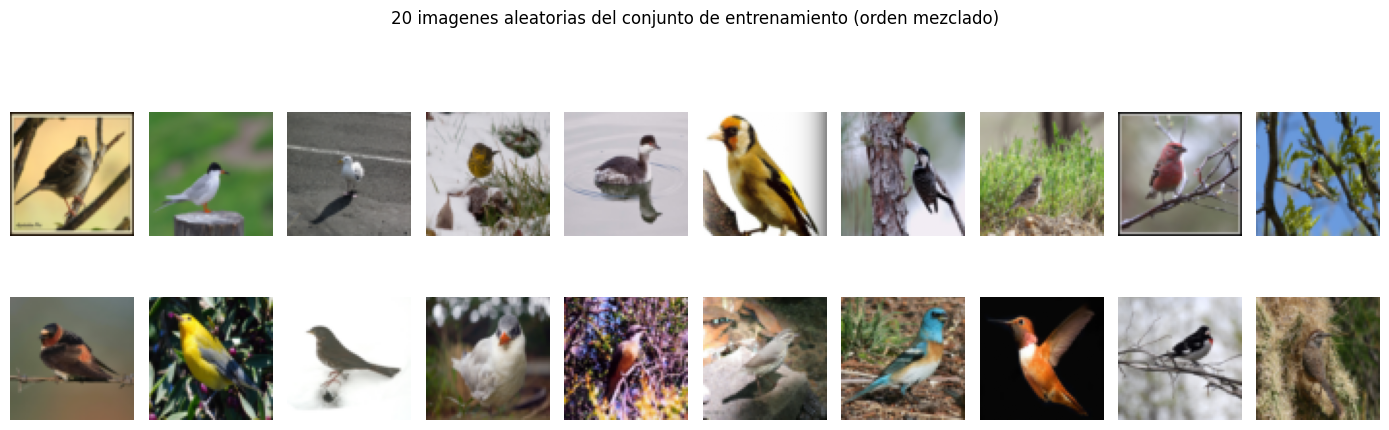

In [ ]:
# Division train / test estratificada para mantener proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}    y_test:  {y_test.shape}")

# Visualizacion de 20 imagenes aleatorias del conjunto de entrenamiento
n_show      = 20
sample_idxs = np.random.choice(len(X_train), n_show, replace=False)

plt.figure(figsize=(14, 5))
for plot_i, idx in enumerate(sample_idxs):
    plt.subplot(2, 10, plot_i + 1)
    img = X_train[idx].reshape(IMG_SIZE, IMG_SIZE, 3)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("20 imagenes aleatorias del conjunto de entrenamiento (orden mezclado)", fontsize=12)
plt.tight_layout()
plt.show()


### 2.3 Estimacion del numero de clases con metodo del codo y silhouette score

Dado que fingimos no conocer cuantas clases hay, usamos el metodo del codo y el silhouette score para estimar un rango razonable de k. Dado que el dataset tiene 200 clases reales pero las imagenes son complejas, se evalua un rango reducido de k para no hacer el computo excesivamente largo.

> Nota: evaluar k desde 2 hasta 200 con 9 000 imagenes de 12 288 dimensiones es costoso computacionalmente. Se evalua un rango representativo y se usa PCA para reducir dimensionalidad antes del clustering.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -----------------------------------------------------------------------
# REDUCCION DE DIMENSIONALIDAD CON PCA ANTES DEL CLUSTERING
# Reducir a 50 componentes captura la mayor parte de la varianza y hace
# el clustering mucho mas rapido y estable.
# -----------------------------------------------------------------------
n_components = 50
print(f"Aplicando PCA con {n_components} componentes ...")
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

varianza_acumulada = pca.explained_variance_ratio_.sum()
print(f"Varianza explicada por {n_components} componentes: {varianza_acumulada:.2%}")

# -----------------------------------------------------------------------
# METODO DEL CODO Y SILHOUETTE SCORE sobre un rango de k
# Se evalua de 5 a 60 en pasos de 5 para cubrir un rango amplio sin
# hacer el computo excesivo.
# -----------------------------------------------------------------------
k_values   = list(range(5, 65, 5))
inertias2  = []
sil_scores = []

print()
print("Evaluando k valores (esto puede tardar varios minutos) ...")
for ki in k_values:
    km = KMeans(n_clusters=ki, random_state=42, n_init=5, max_iter=200)
    km.fit(X_train_pca)
    inertias2.append(km.inertia_)
    sc = silhouette_score(X_train_pca, km.labels_, sample_size=2000, random_state=42)
    sil_scores.append(sc)
    print(f"  k={ki:3d}  inercia={km.inertia_:.0f}  silhouette={sc:.4f}")

best_k_idx = np.argmax(sil_scores)
best_k_cub = k_values[best_k_idx]
print()
print(f"Mejor k segun silhouette score: {best_k_cub} (score={sil_scores[best_k_idx]:.4f})")
print(f"Numero real de clases en el dataset: {n_clases_reales}")


Aplicando PCA con 50 componentes ...
Varianza explicada por 50 componentes: 77.66%

Evaluando k valores (esto puede tardar varios minutos) ...
  k=  5  inercia=2594312  silhouette=0.1168
  k= 10  inercia=2312014  silhouette=0.0733
  k= 15  inercia=2173093  silhouette=0.0601
  k= 20  inercia=2082223  silhouette=0.0499
  k= 25  inercia=2027145  silhouette=0.0415
  k= 30  inercia=1972023  silhouette=0.0337
  k= 35  inercia=1931525  silhouette=0.0288
  k= 40  inercia=1906040  silhouette=0.0213
  k= 45  inercia=1871543  silhouette=0.0215
  k= 50  inercia=1849197  silhouette=0.0233
  k= 55  inercia=1826545  silhouette=0.0194
  k= 60  inercia=1807091  silhouette=0.0169

Mejor k segun silhouette score: 5 (score=0.1168)
Numero real de clases en el dataset: 200


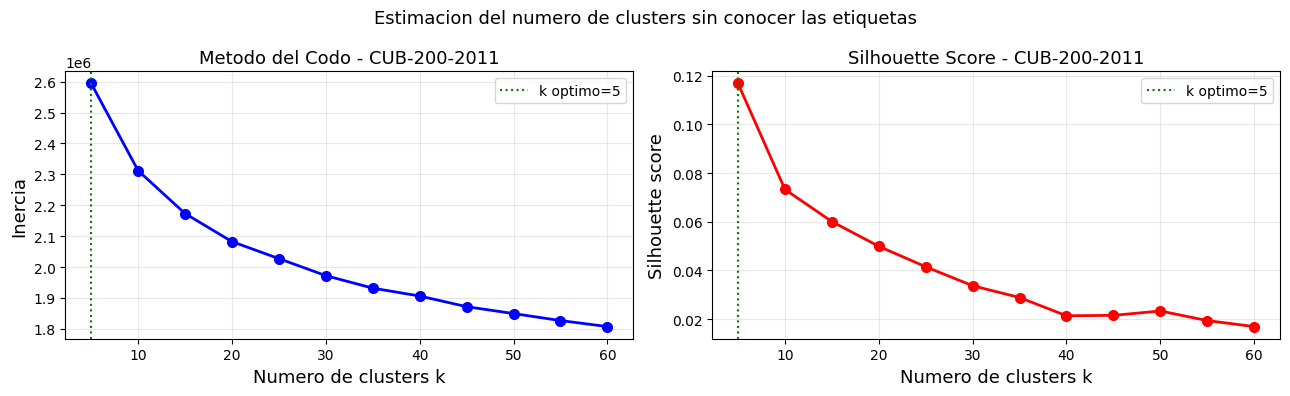

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_values, inertias2, "bo-", linewidth=2, markersize=7)
axes[0].set_xlabel("Numero de clusters k", fontsize=13)
axes[0].set_ylabel("Inercia", fontsize=13)
axes[0].set_title("Metodo del Codo - CUB-200-2011", fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_k_cub, color='green', linestyle=':', label=f"k optimo={best_k_cub}")
axes[0].legend()

axes[1].plot(k_values, sil_scores, "ro-", linewidth=2, markersize=7)
axes[1].set_xlabel("Numero de clusters k", fontsize=13)
axes[1].set_ylabel("Silhouette score", fontsize=13)
axes[1].set_title("Silhouette Score - CUB-200-2011", fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=best_k_cub, color='green', linestyle=':', label=f"k optimo={best_k_cub}")
axes[1].legend()

plt.suptitle("Estimacion del numero de clusters sin conocer las etiquetas", fontsize=13)
plt.tight_layout()
plt.show()


---
### 2.4 Aprendizaje semi-supervisado con KMeans

Entrenamos KMeans con k=250. Para cada cluster encontramos la imagen mas representativa (la mas cercana al centroide). Luego anotamos esas 250 imagenes con sus etiquetas reales (hacemos trampa), entrenamos un clasificador con ellas y comparamos con 250 imagenes aleatorias.

La idea es demostrar que seleccionar datos de forma inteligente produce un mejor clasificador con la misma cantidad de anotaciones.


In [ ]:
from sklearn.cluster import KMeans

k_semi = 250

print(f"Entrenando KMeans con k={k_semi} sobre {X_train_pca.shape[0]:,} imagenes (espacio PCA) ...")
kmeans_semi     = KMeans(n_clusters=k_semi, random_state=42, n_init=5, max_iter=300)
X_digits_dist   = kmeans_semi.fit_transform(X_train_pca)   # forma: (n_train, k_semi)

print(f"KMeans entrenado. Inercia: {kmeans_semi.inertia_:.2f}")
print(f"Forma de la matriz de distancias: {X_digits_dist.shape}")

Entrenando KMeans con k=250 sobre 9,436 imagenes (espacio PCA) ...
KMeans entrenado. Inercia: 1510609.38
Forma de la matriz de distancias: (9436, 250)


Imagenes representativas seleccionadas: 250
Se anotaron 250 imagenes de un total de 9,436


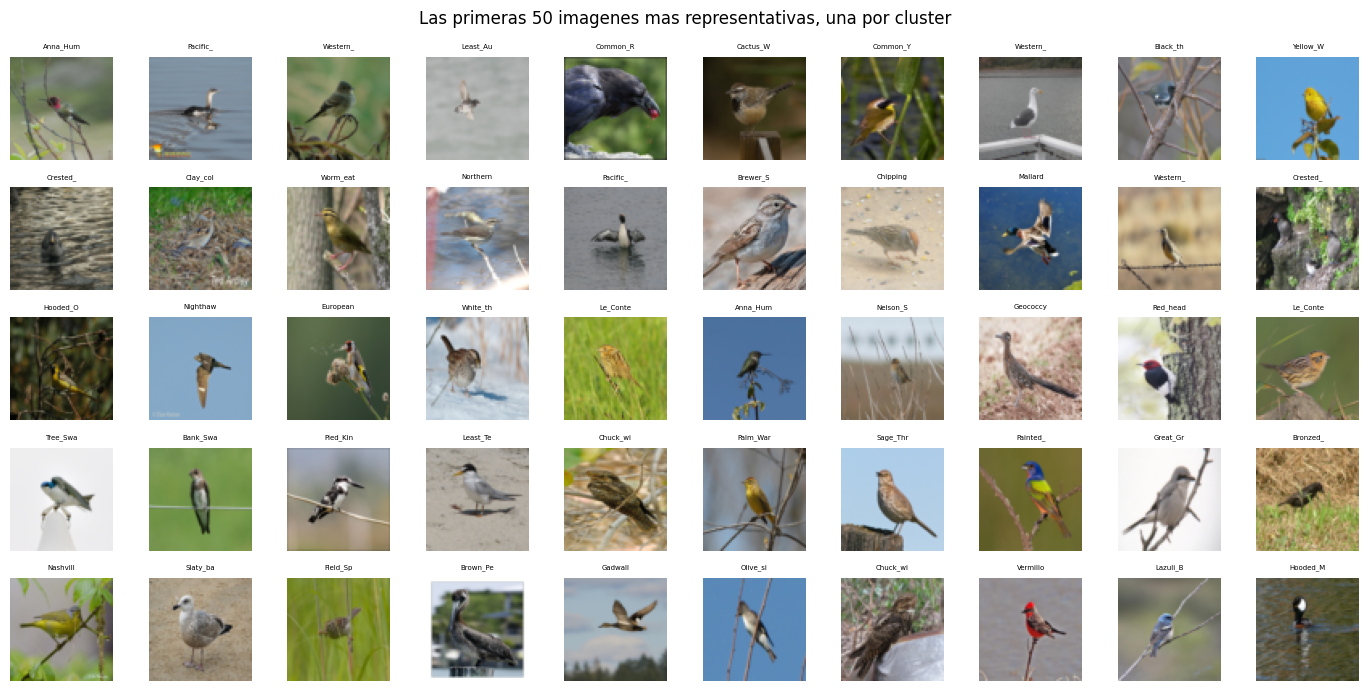

In [ ]:
# Encontrar la imagen mas cercana al centroide de cada cluster
idxs_repr = np.argmin(X_digits_dist, axis=0)    # Un indice por cluster
X_repr    = X_train[idxs_repr]                   # Imagenes originales (no PCA)
y_repr    = y_train[idxs_repr]                   # Etiquetas reales

print(f"Imagenes representativas seleccionadas: {X_repr.shape[0]}")
print(f"Se anotaron {len(y_repr)} imagenes de un total de {len(X_train):,}")

# Visualizar las imagenes representativas (limitado a 50 para encajar en el plot)
plt.figure(figsize=(14, 7))
for i in range(min(k_semi, 50)): # Limit to 50 images for display
    plt.subplot(5, 10, i + 1)
    img = X_repr[i].reshape(IMG_SIZE, IMG_SIZE, 3)
    plt.imshow(img)
    plt.title(class_names[y_repr[i]].split(".")[-1][:8], fontsize=5)
    plt.axis("off")

plt.suptitle(f"Las primeras {min(k_semi, 50)} imagenes mas representativas, una por cluster", fontsize=12)
plt.tight_layout()
plt.show()

### 2.5 Comparacion entre representantes y muestras aleatorias

Se entrena un clasificador con las 250 imagenes representativas y otro con 250 imagenes elegidas al azar, usando el modelo LogisticRegression


In [ ]:
from sklearn.linear_model import LogisticRegression

# Clasificador 1: entrenado con las 50 imagenes representativas
print("Entrenando con imagenes representativas ...")
log_reg_repr = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                   max_iter=5000, random_state=42)
log_reg_repr.fit(X_repr, y_repr)
acc_repr = log_reg_repr.score(X_test, y_test)
print(f"  Precision (50 representativas): {acc_repr:.4f}  ({acc_repr*100:.2f}%)")

# Clasificador 2: entrenado con 50 imagenes aleatorias
print("Entrenando con imagenes aleatorias ...")
random_idxs    = np.random.choice(len(X_train), 50, replace=False)
log_reg_random = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                     max_iter=5000, random_state=42)
log_reg_random.fit(X_train[random_idxs], y_train[random_idxs])
acc_random = log_reg_random.score(X_test, y_test)
print(f"  Precision (50 aleatorias):      {acc_random:.4f}  ({acc_random*100:.2f}%)")

print()
print(f"Mejora usando representantes vs aleatorias: {(acc_repr - acc_random)*100:+.2f} puntos porcentuales")


Entrenando con imagenes representativas ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Precision (50 representativas): 0.0131  (1.31%)
Entrenando con imagenes aleatorias ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Precision (50 aleatorias):      0.0106  (1.06%)

Mejora usando representantes vs aleatorias: +0.25 puntos porcentuales


### 2.6 Propagacion de etiquetas

Se asigna a todas las imagenes del conjunto de entrenamiento la misma etiqueta que la imagen representativa de su cluster. Esto permite entrenar con muchos mas datos, aunque algunos estaran mal etiquetados porque no todas las imagenes del cluster pertenecen exactamente a la misma clase.


In [ ]:
# Propagar la etiqueta del representante a todas las imagenes del mismo cluster
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k_semi):
    y_train_propagated[kmeans_semi.labels_ == i] = y_repr[i]

# Entrenar con los primeros 1000 ejemplos propagados
print("Entrenando con etiquetas propagadas (1000 ejemplos) ...")
log_reg_prop = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                   max_iter=5000, random_state=42)
log_reg_prop.fit(X_train[:1000], y_train_propagated[:1000])
acc_prop = log_reg_prop.score(X_test, y_test)
print(f"  Precision (propagacion 1000 imgs): {acc_prop:.4f}  ({acc_prop*100:.2f}%)")

print()
print("La propagacion puede empeorar o mejorar segun la pureza de los clusters.")
print("El ruido introducido por asignaciones incorrectas afecta al clasificador.")


Entrenando con etiquetas propagadas (1000 ejemplos) ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Precision (propagacion 1000 imgs): 0.0119  (1.19%)

La propagacion puede empeorar o mejorar segun la pureza de los clusters.
El ruido introducido por asignaciones incorrectas afecta al clasificador.


---
### 2.7 Aprendizaje Activo - Iteracion 1

El aprendizaje activo mejora el clasificador de forma iterativa. En cada ciclo se identifican los ejemplos donde el modelo tiene mayor incertidumbre (aquellos con la probabilidad maxima de prediccion mas baja), se anotan con sus etiquetas reales y se reentrenan el modelo. Esto es mas eficiente que anotar ejemplos aleatorios porque se enfoca el esfuerzo donde mas falta hace.


In [ ]:
# Calcular probabilidades del clasificador con etiquetas propagadas
probas     = log_reg_prop.predict_proba(X_train[:1000])

# Para cada ejemplo, extraer la probabilidad de la clase predicha (confianza)
labels_ixs = np.argmax(probas, axis=1)
max_probas  = np.array([probas[i, ix] for i, ix in enumerate(labels_ixs)])

# Ordenar de menor a mayor confianza: los primeros son los mas inciertos
sorted_ixs = np.argsort(max_probas)

print("Los 10 ejemplos con menor confianza (mayor incertidumbre):")
for pos, idx in enumerate(sorted_ixs[:10]):
    pred_class = class_names[labels_ixs[idx]].split(".")[-1]
    real_class = class_names[y_train[idx]].split(".")[-1]
    print(f"  [{pos+1:2d}] idx={idx:4d}  confianza={max_probas[idx]:.4f}  "
          f"pred={pred_class[:18]:<18}  real={real_class[:18]}")


Los 10 ejemplos con menor confianza (mayor incertidumbre):
  [ 1] idx= 196  confianza=0.4579  pred=Brandt_Cormorant    real=Cardinal
  [ 2] idx= 634  confianza=0.5048  pred=Brandt_Cormorant    real=Pacific_Loon
  [ 3] idx= 350  confianza=0.5833  pred=California_Gull     real=Ruby_throated_Humm
  [ 4] idx= 603  confianza=0.6082  pred=Grasshopper_Sparro  real=Northern_Waterthru
  [ 5] idx= 771  confianza=0.6337  pred=Brandt_Cormorant    real=Cerulean_Warbler
  [ 6] idx= 825  confianza=0.6509  pred=Grasshopper_Sparro  real=Florida_Jay
  [ 7] idx= 725  confianza=0.6762  pred=Nelson_Sharp_taile  real=Nighthawk
  [ 8] idx= 224  confianza=0.7033  pred=Brown_Pelican       real=Eared_Grebe
  [ 9] idx= 852  confianza=0.7102  pred=Horned_Puffin       real=Red_winged_Blackbi
  [10] idx= 781  confianza=0.7234  pred=Nelson_Sharp_taile  real=Yellow_bellied_Fly


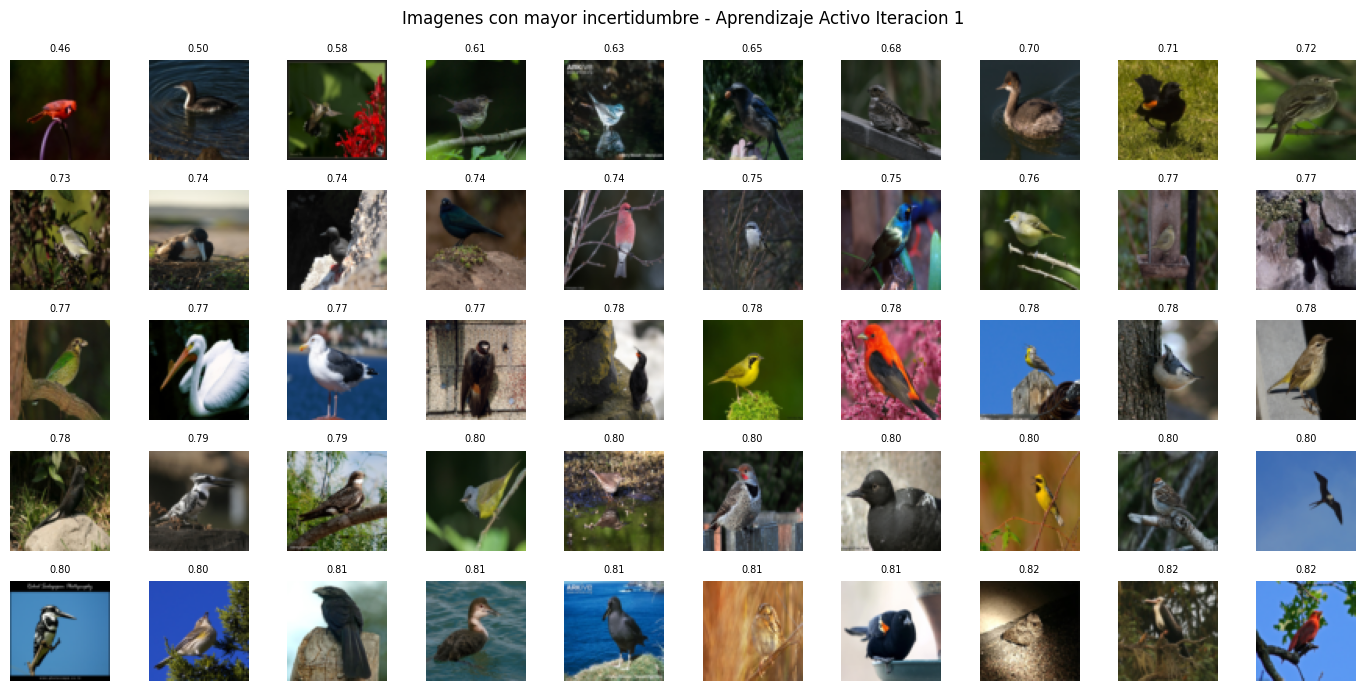

In [ ]:
# Visualizar las imagenes con mayor incertidumbre (los primeros 50)
n_uncertain = k_semi
X_uncertain = X_train[:1000][sorted_ixs[:n_uncertain]]

plt.figure(figsize=(14, 7))
for i in range(min(n_uncertain, 50)):
    plt.subplot(5, 10, i + 1)
    img = X_uncertain[i].reshape(IMG_SIZE, IMG_SIZE, 3)
    plt.imshow(img)
    plt.title(f"{max_probas[sorted_ixs[i]]:.2f}", fontsize=7)
    plt.axis("off")

plt.suptitle("Imagenes con mayor incertidumbre - Aprendizaje Activo Iteracion 1", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Reemplazar las etiquetas propagadas de los ejemplos inciertos con las reales
y_uncertain   = y_train[:1000][sorted_ixs[:n_uncertain]]

y_train_active = y_train_propagated[:1000].copy()
y_train_active[sorted_ixs[:n_uncertain]] = y_uncertain

# Reentrenar el clasificador con el conjunto mejorado
print("Entrenando clasificador con aprendizaje activo (iteracion 1) ...")
log_reg_active = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                     max_iter=5000, random_state=42)
log_reg_active.fit(X_train[:1000], y_train_active)
acc_active = log_reg_active.score(X_test, y_test)
print(f"  Precision (activo iteracion 1): {acc_active:.4f}  ({acc_active*100:.2f}%)")


Entrenando clasificador con aprendizaje activo (iteracion 1) ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


### 2.8 Aprendizaje Activo - Iteracion 2

Se repite el ciclo usando el modelo mejorado. Al tener un clasificador mas preciso, los nuevos ejemplos inciertos que detecta son distintos a los de la primera iteracion y aportan informacion diferente al modelo.


In [ ]:
# Segunda ronda de aprendizaje activo con el modelo ya mejorado
probas2      = log_reg_active.predict_proba(X_train[:1000])
labels_ixs2  = np.argmax(probas2, axis=1)
max_probas2  = np.array([probas2[i, ix] for i, ix in enumerate(labels_ixs2)])
sorted_ixs2  = np.argsort(max_probas2)

print("Los 10 ejemplos mas inciertos en la iteracion 2:")
for pos, idx in enumerate(sorted_ixs2[:10]):
    pred_class = class_names[labels_ixs2[idx]].split(".")[-1]
    real_class = class_names[y_train[idx]].split(".")[-1]
    print(f"  [{pos+1:2d}] idx={idx:4d}  confianza={max_probas2[idx]:.4f}  "
          f"pred={pred_class[:18]:<18}  real={real_class[:18]}")

# Anotar la nueva ronda
y_uncertain2    = y_train[:1000][sorted_ixs2[:n_uncertain]]
y_train_active2 = y_train_active.copy()
y_train_active2[sorted_ixs2[:n_uncertain]] = y_uncertain2

print()
print("Entrenando clasificador con aprendizaje activo (iteracion 2) ...")
log_reg_active2 = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                      max_iter=5000, random_state=42)
log_reg_active2.fit(X_train[:1000], y_train_active2)
acc_active2 = log_reg_active2.score(X_test, y_test)
print(f"  Precision (activo iteracion 2): {acc_active2:.4f}  ({acc_active2*100:.2f}%)")


Los 10 ejemplos mas inciertos en la iteracion 2:
  [ 1] idx= 196  confianza=0.3132  pred=Indigo_Bunting      real=Cardinal
  [ 2] idx= 634  confianza=0.4098  pred=Tropical_Kingbird   real=Pacific_Loon
  [ 3] idx= 350  confianza=0.4888  pred=Glaucous_winged_Gu  real=Ruby_throated_Humm
  [ 4] idx= 825  confianza=0.5165  pred=Slaty_backed_Gull   real=Florida_Jay
  [ 5] idx= 603  confianza=0.5310  pred=Warbling_Vireo      real=Northern_Waterthru
  [ 6] idx= 852  confianza=0.5685  pred=Rhinoceros_Auklet   real=Red_winged_Blackbi
  [ 7] idx= 771  confianza=0.6052  pred=Tree_Swallow        real=Cerulean_Warbler
  [ 8] idx= 224  confianza=0.6142  pred=Yellow_bellied_Fly  real=Eared_Grebe
  [ 9] idx= 725  confianza=0.6307  pred=Ringed_Kingfisher   real=Nighthawk
  [10] idx= 312  confianza=0.6325  pred=Yellow_breasted_Ch  real=Red_faced_Cormoran

Entrenando clasificador con aprendizaje activo (iteracion 2) ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Precision (activo iteracion 2): 0.0148  (1.48%)


### 2.9 Comparacion final de todos los enfoques


In [49]:
metodos = [
    ("Aleatorio (50 imgs)",              acc_random),
    ("Semi-supervisado (50 repr.)",      acc_repr),
    ("Propagacion (1000 imgs)",          acc_prop),
    ("Activo - Iteracion 1",             acc_active),
    ("Activo - Iteracion 2",             acc_active2),
]

print("=" * 60)
print("  COMPARACION FINAL - DATASET CUB-200-2011")
print("=" * 60)
for nombre, acc in metodos:
    barra = "#" * int(acc * 60)
    print(f"  {nombre:<30}  {acc*100:5.2f}%  {barra}")
print("=" * 60)



  COMPARACION FINAL - DATASET CUB-200-2011
  Aleatorio (50 imgs)              1.06%  
  Semi-supervisado (50 repr.)      1.31%  
  Propagacion (1000 imgs)          1.19%  
  Activo - Iteracion 1             1.40%  
  Activo - Iteracion 2             1.48%  
